Base de demonstração carregada: 391944 registros do arquivo cat01_non_alcoholic.csv.


,date,quantity,lag_1,lag_7,rolling_mean_3,rolling_mean_7
28456,2019-01-02,19.0,NaN,NaN,NaN,NaN
28457,2019-01-03,22.0,19.0,NaN,NaN,NaN
28458,2019-01-04,17.0,22.0,NaN,NaN,NaN
28459,2019-01-05,19.0,17.0,NaN,19.333333,NaN
28460,2019-01-06,12.0,19.0,NaN,19.333333,NaN
28461,2019-01-07,20.0,12.0,NaN,16.000000,NaN
28462,2019-01-08,29.0,20.0,NaN,17.000000,NaN
28463,2019-01-09,13.0,29.0,19.0,20.333333,19.714286
28464,2019-01-10,9.0,13.0,22.0,20.666667,18.857143
28465,2019-01-11,7.0,9.0,17.0,17.000000,17.000000


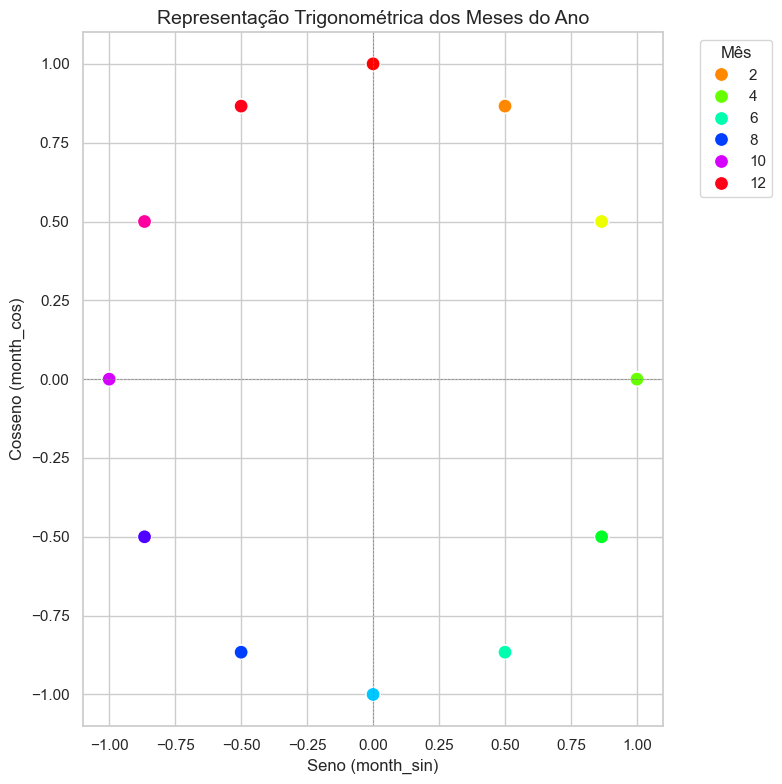

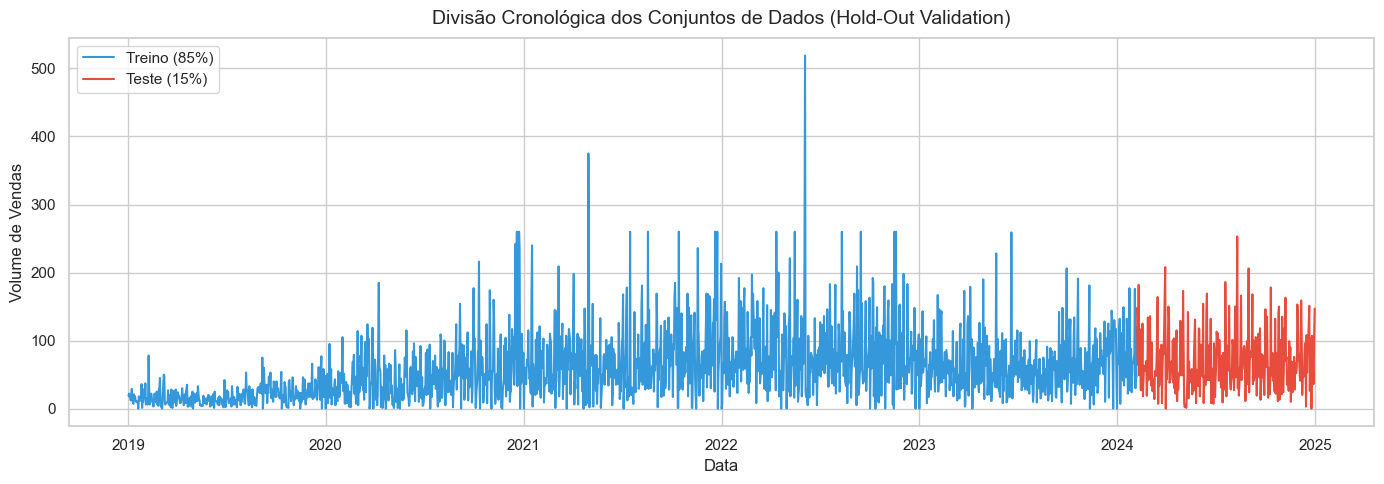

Formato original do DataFrame: (2191, 5) (2D)
Formato final do Tensor RNN:  (2184, 7, 5) (3D) -> [Amostras, Tempo, Features]
Formato do Vetor de Resposta:  (2184,) (1D)


In [4]:
# %% [markdown]
# # Processamento e Engenharia de Atributos (Feature Engineering)
# 
# ## Objetivo
# Demonstrar visualmente a transformação dos dados brutos em tensores matemáticos 3D, detalhando a criação de atributos temporais, construção de variáveis defasadas (*lags*), tratamento de sazonalidade cíclica e o particionamento temporal estrito.
# 
# ## Contextualização
# Após a análise exploratória (EDA), torna-se necessário estruturar um pipeline de processamento capaz de transformar os dados temporais em representações adequadas para algoritmos de Machine Learning e Deep Learning.
# 
# Em problemas de previsão de demanda no varejo, Redes Neurais (LSTM/GRU) e Árvores de Decisão (XGBoost) não compreendem o conceito de "tempo" nativamente. Cabe ao Engenheiro de Dados traduzir o histórico de vendas em atrasos (*Lags*), codificações cíclicas (Seno/Cosseno) e, no caso do Deep Learning, converter matrizes 2D em Tensores 3D através de Janelas Deslizantes (*Sliding Windows*).

# %%
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Adiciona a raiz do projeto ao sys.path
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.reproducibility import set_global_seed

# Configuração visual e reprodutibilidade
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
set_global_seed(42)

# Carregando a base de dados
DATA_PATH = ROOT / "Dados" / "preprocessed"
market_path = next(DATA_PATH.iterdir())
csv_file = next(market_path.glob("cat*.csv"))

df = pd.read_csv(csv_file, parse_dates=["date"])
df = df.sort_values(["product_id", "date"])

print(f"Base de demonstração carregada: {len(df)} registros do arquivo {csv_file.name}.")

# %% [markdown]
# ## 1. Construção de Variáveis Defasadas (*Lags* e Médias Móveis)
# As variáveis defasadas entregam o histórico explícito na mesma linha matemática. Isso é vital para o XGBoost, que não possui células de estado interno (memória) como a arquitetura LSTM.

# %%
# Isolando um único produto para visualização clara
df_amostra = df[df['product_id'] == df['product_id'].iloc[0]].copy()

TARGET = "quantity"
LAGS = [1, 7, 14]
ROLLING_WINDOWS = [3, 7]

# Recriando a lógica de Lags e Médias Móveis
for lag in LAGS:
    df_amostra[f'lag_{lag}'] = df_amostra[TARGET].shift(lag)

for window in ROLLING_WINDOWS:
    # shift(1) garante que a média móvel não olhe para o dia atual (Data Leakage)
    df_amostra[f'rolling_mean_{window}'] = df_amostra[TARGET].shift(1).rolling(window=window).mean()

# Visualizando a transformação
cols_demonstracao = ['date', TARGET, 'lag_1', 'lag_7', 'rolling_mean_3', 'rolling_mean_7']
display(df_amostra[cols_demonstracao].head(10))

# %% [markdown]
# > **Análise Técnica:** Os primeiros dias geram valores `NaN` (Not a Number). No pipeline oficial, aplicamos o `dropna()` estrito nessas colunas para garantir que o *Baseline* e a Inteligência Artificial prevejam apenas sobre dias com histórico observável perfeito.
# 
# ---
# ## 2. A Matemática do Tempo: Features Cíclicas (Trigonometria)
# Para redes neurais, a distância escalar entre o mês 12 e o mês 1 é enorme (11 unidades), o que prejudica a retropropagação do gradiente. A conversão de meses e dias para coordenadas circulares (Seno e Cosseno) resolve este problema topológico.

# %%
# Plotando a representação cíclica do tempo
plt.figure(figsize=(8, 8))
sns.scatterplot(x=df_amostra['month_sin'], y=df_amostra['month_cos'], 
                hue=df_amostra['month'], palette='hsv', s=100)

plt.title("Representação Trigonométrica dos Meses do Ano", fontsize=14)
plt.xlabel("Seno (month_sin)", fontsize=12)
plt.ylabel("Cosseno (month_cos)", fontsize=12)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.legend(title="Mês", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# %% [markdown]
# > **Veredito Acadêmico:** O gráfico circular comprova que Dezembro (12) e Janeiro (1) estão matematicamente adjacentes nesta representação vetorial, permitindo interpolações sazonais contínuas.
# 
# ---
# ## 3. Split Temporal Estrito (Prevenção de Data Leakage)
# Em Séries Temporais, utilizar amostragem aleatória causa vazamento de dados (o modelo decora o futuro para prever o passado). Nosso pipeline realiza o particionamento em ordem estritamente cronológica. 
# Conforme definição metodológica, a base foi dividida em 85% para a fase de aprendizado contínuo e os 15% finais separados como holdout de teste, abolindo o conjunto de validação.

# %%
def temporal_split_demonstration(df_produto, train_ratio=0.85):
    n = len(df_produto)
    train_end = int(n * train_ratio)

    train = df_produto.iloc[:train_end]
    test  = df_produto.iloc[train_end:]

    return train, test

train, test = temporal_split_demonstration(df_amostra)

plt.figure(figsize=(14, 5))
plt.plot(train['date'], train[TARGET], label='Treino (85%)', color='#3498db', linewidth=1.5)
plt.plot(test['date'], test[TARGET], label='Teste (15%)', color='#e74c3c', linewidth=1.5)

plt.title("Divisão Cronológica dos Conjuntos de Dados (Hold-Out Validation)", fontsize=14, pad=10)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Volume de Vendas", fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# %% [markdown]
# ---
# ## 4. A Transformação em Tensores 3D (Sliding Windows)
# Enquanto o XGBoost consome matrizes 2D clássicas (`[linhas, features]`), a arquitetura LSTM/GRU exige a dimensão temporal explícita. Nós transformamos o DataFrame em Tensores Numpy 3D com a forma `[amostras, janela_de_tempo, features]`.

# %%
def create_sequences_demonstration(data, features, target, window_size):
    X, y = [], []
    values_x = data[features].values
    values_y = data[target].values

    for i in range(len(data) - window_size):
        X.append(values_x[i : i + window_size])
        y.append(values_y[i + window_size])
        
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Definindo uma janela de 7 dias olhando para as features principais
features_exemplo = ['lag_1', 'lag_7', 'rolling_mean_3', 'month_sin', 'month_cos']
WINDOW_SIZE = 7

# Preenchendo NaNs provisoriamente apenas para a matemática da demonstração rodar sem quebrar
df_amostra = df_amostra.fillna(0)

X_tensor, y_tensor = create_sequences_demonstration(df_amostra, features_exemplo, TARGET, WINDOW_SIZE)

print(f"Formato original do DataFrame: {df_amostra[features_exemplo].shape} (2D)")
print(f"Formato final do Tensor RNN:  {X_tensor.shape} (3D) -> [Amostras, Tempo, Features]")
print(f"Formato do Vetor de Resposta:  {y_tensor.shape} (1D)")

# %% [markdown]
# > **Considerações Finais do Pipeline**
# > Ao final desta fase, os dados brutos foram higienizados, enriquecidos com trigonometria, blindados contra vazamento de dados cronológicos (obedecendo a proporção 85/15) e remodelados geometricamente. Esta base matemática sólida garante estabilidade de convergência nas arquiteturas avaliadas na pesquisa.